In [3]:
# Imports
import sys
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Import metrics from codebase
# Add src to path
project_root = Path.cwd().parents[2]
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

from data.metrics import calculate_depth_dose_metrics

In [4]:
dat_files_dir = Path(r"C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\mc_ccb\big")

In [5]:
# File paths - each .dat file has 3 columns: X coordinate, quantity, uncertainty
mc_fluence_profile_path = dat_files_dir / Path('entryx_p1.dat')
mc_kinetic_energy_path = dat_files_dir / Path('entryx_p2.dat')
mc_dose_profile_path = dat_files_dir / Path('entryx_p3.dat')

print("Fluence file exists:", mc_fluence_profile_path.exists())
print("Kinetic energy file exists:", mc_kinetic_energy_path.exists())
print("Dose file exists:", mc_dose_profile_path.exists())

Fluence file exists: True
Kinetic energy file exists: True
Dose file exists: True


In [6]:
def load_dat_file(filepath: Path, column_names: list) -> pd.DataFrame:
    """
    Load a .dat file with space-separated values (X coordinate, quantity, uncertainty).
    
    Parameters:
    - filepath: Path to the .dat file
    - column_names: List of column names ['x', 'quantity', 'uncertainty']
    
    Returns:
    - DataFrame with the loaded data
    """
    df = pd.read_csv(filepath, sep=r'\s+', header=None, names=column_names)
    return df

In [7]:
# Load all three .dat files
df_fluence = load_dat_file(mc_fluence_profile_path, ['x_cm', 'fluence', 'fluence_err'])
df_kinetic = load_dat_file(mc_kinetic_energy_path, ['x_cm', 'kinetic_energy', 'kinetic_energy_err'])
df_dose = load_dat_file(mc_dose_profile_path, ['x_cm', 'dose', 'dose_err'])

print("Fluence data shape:", df_fluence.shape)
print("Kinetic energy data shape:", df_kinetic.shape)
print("Dose data shape:", df_dose.shape)

# Verify that X columns are the same
print("\n--- Verifying X columns are identical ---")
print(f"Dose vs Fluence: {df_dose['x_cm'].equals(df_fluence['x_cm'])}")
print(f"Dose vs Kinetic: {df_dose['x_cm'].equals(df_kinetic['x_cm'])}")

if not (df_dose['x_cm'].equals(df_fluence['x_cm']) and df_dose['x_cm'].equals(df_kinetic['x_cm'])):
    print("WARNING: X columns are not identical!")
    print(f"Max difference (Dose vs Fluence): {(df_dose['x_cm'] - df_fluence['x_cm']).abs().max()}")
    print(f"Max difference (Dose vs Kinetic): {(df_dose['x_cm'] - df_kinetic['x_cm']).abs().max()}")
else:
    print("✓ All X columns are identical\n")

# Create the merged dataframe with normalized dose and all uncertainties
df_merged = pd.DataFrame({
    'depth': df_dose['x_cm'] * 10,  # Convert from cm to mm
    'dose': df_dose['dose'] / df_dose['dose'].max(),  # Normalize dose to max value of 1
    'dose_err': df_dose['dose_err'] / df_dose['dose'].max(),  # Normalize uncertainty with same factor
    'fluence': df_fluence['fluence'],
    'fluence_err': df_fluence['fluence_err'],
    'kinetic_energy': df_kinetic['kinetic_energy'],
    'kinetic_energy_err': df_kinetic['kinetic_energy_err']
})

print(f"Merged dataframe shape: {df_merged.shape}")
print(f"Columns: {df_merged.columns.tolist()}")
print("\nFirst few rows:")
print(df_merged.head())
print("\nData summary:")
print(df_merged.describe())

Fluence data shape: (1000, 3)
Kinetic energy data shape: (1000, 3)
Dose data shape: (1000, 3)

--- Verifying X columns are identical ---
Dose vs Fluence: True
Dose vs Kinetic: True
✓ All X columns are identical

Merged dataframe shape: (1000, 7)
Columns: ['depth', 'dose', 'dose_err', 'fluence', 'fluence_err', 'kinetic_energy', 'kinetic_energy_err']

First few rows:
    depth      dose  dose_err   fluence  fluence_err  kinetic_energy  \
0 -24.975  0.000130  0.000036  0.000309     0.000005        0.381631   
1 -24.925  0.000108  0.000028  0.000313     0.000005        0.350285   
2 -24.875  0.000086  0.000021  0.000316     0.000006        0.372667   
3 -24.825  0.000091  0.000021  0.000317     0.000006        0.377567   
4 -24.775  0.000114  0.000026  0.000324     0.000006        0.559975   

   kinetic_energy_err  
0            0.099205  
1            0.099274  
2            0.102462  
3            0.098508  
4            0.126521  

Data summary:
              depth         dose     dos

In [8]:
def plot_mc_data(df, title, linewidth=1, markersize=1, marker1='.', marker2='.', marker3='.', 
                 show_errors=True, error_alpha=0.3):
    """
    Plot MC data with dose, fluence, and kinetic energy on separate y-axes.
    
    Parameters:
    - df: DataFrame with columns ['depth', 'dose', 'fluence', 'kinetic_energy']
          and optionally ['dose_err', 'fluence_err', 'kinetic_energy_err']
    - title: Plot title
    - linewidth: Width of the lines
    - markersize: Size of the markers
    - marker1, marker2, marker3: Marker styles for dose, fluence, and kinetic energy
    - show_errors: Whether to show error bands (if error columns available)
    - error_alpha: Transparency of error bands
    """
    if df is None or df.empty:
        print("Data not loaded")
        return
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot on primary y-axis (dose)
    color1 = 'tab:blue'
    ax.set_xlabel('Depth (mm)', fontsize=12)
    ax.set_ylabel('Normalized Dose', color=color1, fontsize=12)
    line1 = ax.plot(df['depth'], df['dose'], marker=marker1, linestyle='-', 
                    linewidth=linewidth, markersize=markersize, color=color1, label='Dose (normalized)')
    
    # Add error band for dose if available
    if show_errors and 'dose_err' in df.columns:
        ax.fill_between(df['depth'], 
                       df['dose'] - df['dose_err'], 
                       df['dose'] + df['dose_err'], 
                       color=color1, alpha=error_alpha)
    
    ax.tick_params(axis='y', labelcolor=color1)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    
    # Create second y-axis for fluence
    ax2 = ax.twinx()
    color2 = 'tab:orange'
    ax2.set_ylabel('Fluence', color=color2, fontsize=12)
    line2 = ax2.plot(df['depth'], df['fluence'], marker=marker2, linestyle='-', 
                     linewidth=linewidth, markersize=markersize, color=color2, label='Fluence')
    
    # Add error band for fluence if available
    if show_errors and 'fluence_err' in df.columns:
        ax2.fill_between(df['depth'], 
                        df['fluence'] - df['fluence_err'], 
                        df['fluence'] + df['fluence_err'], 
                        color=color2, alpha=error_alpha)
    
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_ylim(bottom=0)
    
    # Create third y-axis for kinetic energy
    ax3 = ax.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    color3 = 'tab:green'
    ax3.set_ylabel('Kinetic Energy', color=color3, fontsize=12)
    line3 = ax3.plot(df['depth'], df['kinetic_energy'], marker=marker3, linestyle='-', 
                     linewidth=linewidth, markersize=markersize, color=color3, label='Kinetic Energy')
    
    # Add error band for kinetic energy if available
    if show_errors and 'kinetic_energy_err' in df.columns:
        ax3.fill_between(df['depth'], 
                        df['kinetic_energy'] - df['kinetic_energy_err'], 
                        df['kinetic_energy'] + df['kinetic_energy_err'], 
                        color=color3, alpha=error_alpha)
    
    ax3.tick_params(axis='y', labelcolor=color3)
    ax3.set_ylim(bottom=0)
    
    # Combine legends
    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='best', fontsize=11)
    
    plt.title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [9]:
# Filter, reverse, and adjust data for specific depth range
if 'df_merged' in locals() and not df_merged.empty:
    # Select rows between -15mm and +17mm
    df_mc = df_merged[(df_merged['depth'] >= -15) & (df_merged['depth'] <= 17)].copy()
    
    print(f"Original data shape: {df_merged.shape}")
    print(f"Filtered data shape: {df_mc.shape}")
    print(f"Depth range: [{df_mc['depth'].min():.2f}, {df_mc['depth'].max():.2f}] mm")
    
    # Reverse all columns (values only, keep depth order)
    for col in ['dose', 'dose_err', 'fluence', 'fluence_err', 'kinetic_energy', 'kinetic_energy_err']:
        df_mc[col] = df_mc[col].iloc[::-1].values
    
    # Add 15mm to depth column
    df_mc['depth'] = df_mc['depth'] + 15
    
    print(f"\nAfter transformation:")
    print(f"Depth range: [{df_mc['depth'].min():.2f}, {df_mc['depth'].max():.2f}] mm")
    print("\nFirst few rows:")
    print(df_mc.head())
    print("\nLast few rows:")
    print(df_mc.tail())
else:
    print("Merged data not loaded")

Original data shape: (1000, 7)
Filtered data shape: (640, 7)
Depth range: [-14.98, 16.98] mm

After transformation:
Depth range: [0.02, 31.98] mm

First few rows:
     depth      dose  dose_err   fluence  fluence_err  kinetic_energy  \
200  0.025  0.258738  0.000850  0.080143     0.000258         60.4629   
201  0.075  0.258574  0.000807  0.080145     0.000248         60.4592   
202  0.125  0.258138  0.000756  0.080005     0.000237         60.4580   
203  0.175  0.258569  0.000796  0.080036     0.000243         60.4450   
204  0.225  0.259069  0.000792  0.080206     0.000239         60.4001   

     kinetic_energy_err  
200            0.003757  
201            0.003779  
202            0.003746  
203            0.003759  
204            0.003698  

Last few rows:
      depth      dose  dose_err   fluence  fluence_err  kinetic_energy  \
835  31.775  0.004642  0.000127  0.001251     0.000018         8.31575   
836  31.825  0.004730  0.000134  0.001261     0.000017         8.27066   
837 

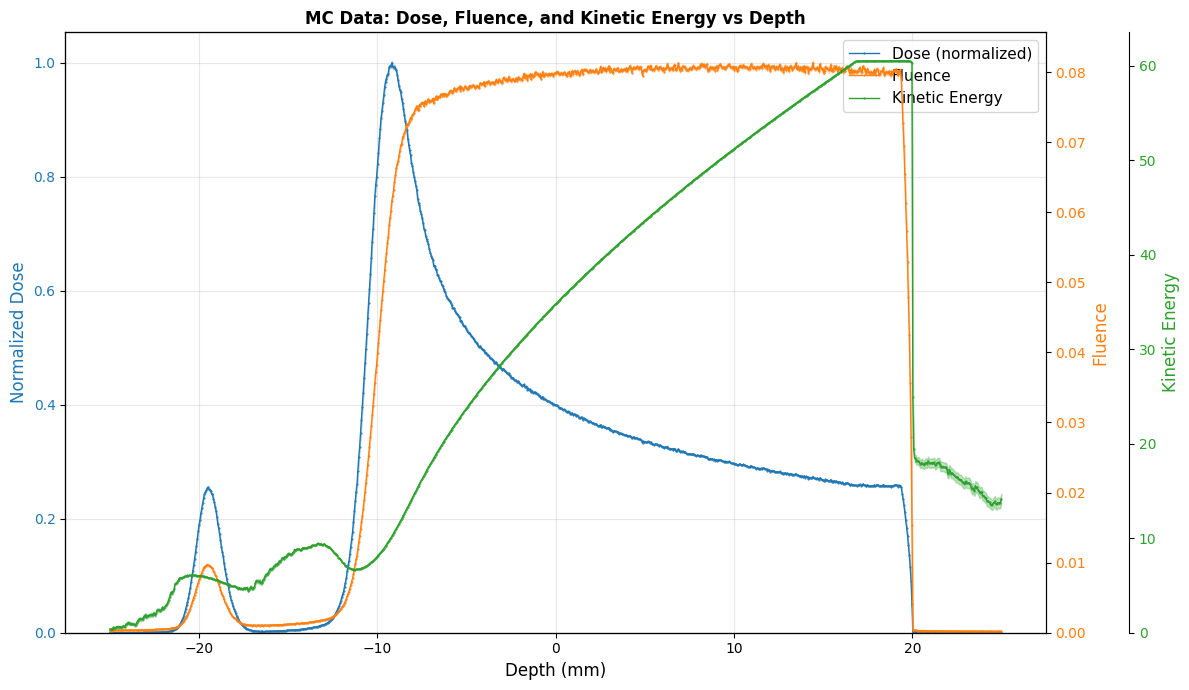

In [10]:
# Plot the merged data
plot_mc_data(df_merged, 'MC Data: Dose, Fluence, and Kinetic Energy vs Depth')

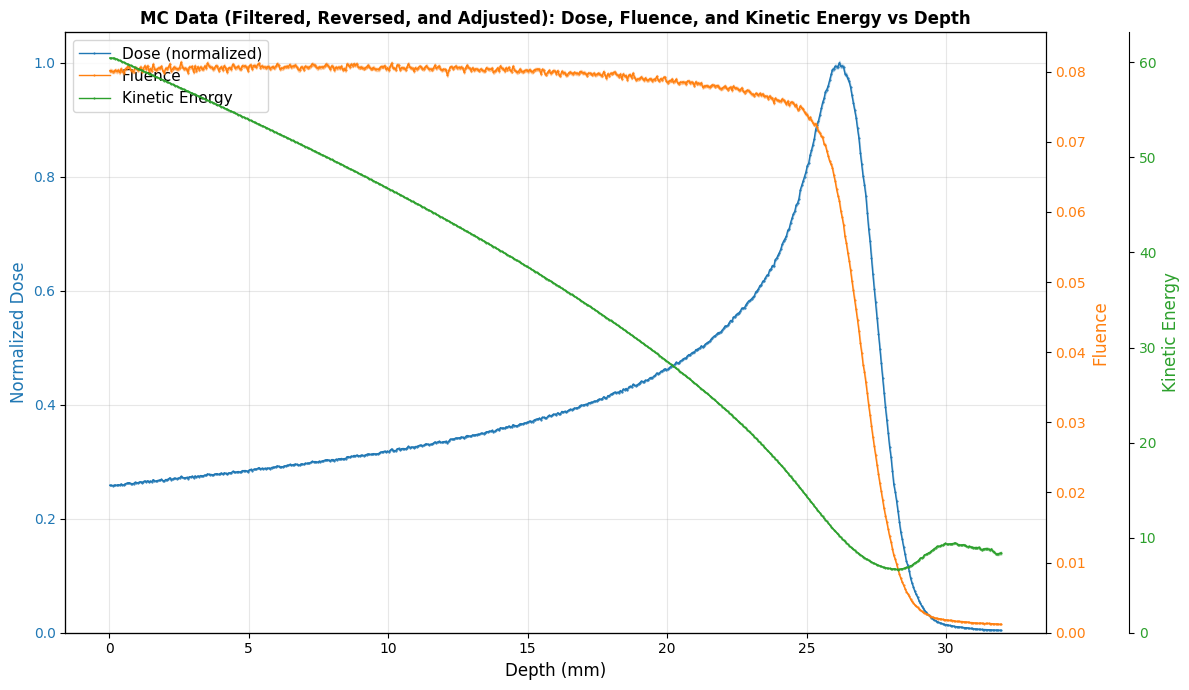

In [11]:
# Plot the filtered, reversed, and adjusted data
plot_mc_data(df_mc, 'MC Data (Filtered, Reversed, and Adjusted): Dose, Fluence, and Kinetic Energy vs Depth')

In [12]:
# Calculate dose metrics for df_mc using the function from codebase
if 'df_mc' in locals() and not df_mc.empty:
    metrics = calculate_depth_dose_metrics(df_mc, "MC Data (big, Filtered & Adjusted)")
else:
    print("MC data not loaded")
    metrics = None

=== MC Data (big, Filtered & Adjusted) Metrics ===
Range (distance at dose 0.9): 2.6784 cm
Distance at dose 0.1: 2.8709 cm
Drop from 0.9 to 0.1: 0.1925 cm
FWHM: 0.6442 cm
Left edge of FWHM (0.5): 2.1180 cm
Right edge of FWHM (0.5): 2.7621 cm
Inverse of first point value: 3.8649



In [13]:
# Save with all columns including uncertainties
df_mc.to_csv('mc_ccb_big.csv', index=False)
print(f"Saved to mc_ccb_big.csv with columns: {df_mc.columns.tolist()}")

Saved to mc_ccb_big.csv with columns: ['depth', 'dose', 'dose_err', 'fluence', 'fluence_err', 'kinetic_energy', 'kinetic_energy_err']


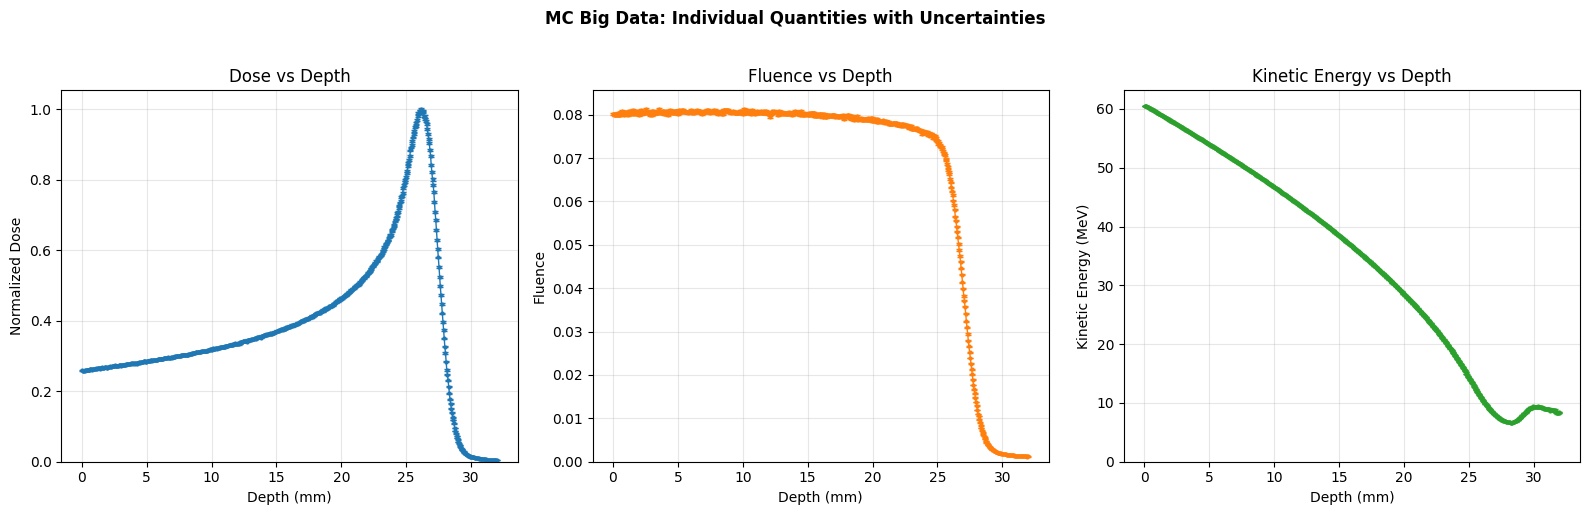

In [14]:
# Additional plot: Individual quantities with error bars
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Dose plot
ax = axes[0]
ax.errorbar(df_mc['depth'], df_mc['dose'], yerr=df_mc['dose_err'], 
            fmt='o-', capsize=2, markersize=2, linewidth=1, label='Dose', color='tab:blue')
ax.set_xlabel('Depth (mm)')
ax.set_ylabel('Normalized Dose')
ax.set_title('Dose vs Depth')
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)

# Fluence plot
ax = axes[1]
ax.errorbar(df_mc['depth'], df_mc['fluence'], yerr=df_mc['fluence_err'], 
            fmt='o-', capsize=2, markersize=2, linewidth=1, label='Fluence', color='tab:orange')
ax.set_xlabel('Depth (mm)')
ax.set_ylabel('Fluence')
ax.set_title('Fluence vs Depth')
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)

# Kinetic Energy plot
ax = axes[2]
ax.errorbar(df_mc['depth'], df_mc['kinetic_energy'], yerr=df_mc['kinetic_energy_err'], 
            fmt='o-', capsize=2, markersize=2, linewidth=1, label='Kinetic Energy', color='tab:green')
ax.set_xlabel('Depth (mm)')
ax.set_ylabel('Kinetic Energy (MeV)')
ax.set_title('Kinetic Energy vs Depth')
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)

plt.suptitle('MC Big Data: Individual Quantities with Uncertainties', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

FWHM: 6.44 mm
Left edge (50%): 21.18 mm
Right edge (50%): 27.62 mm
90% distal position: 26.78 mm


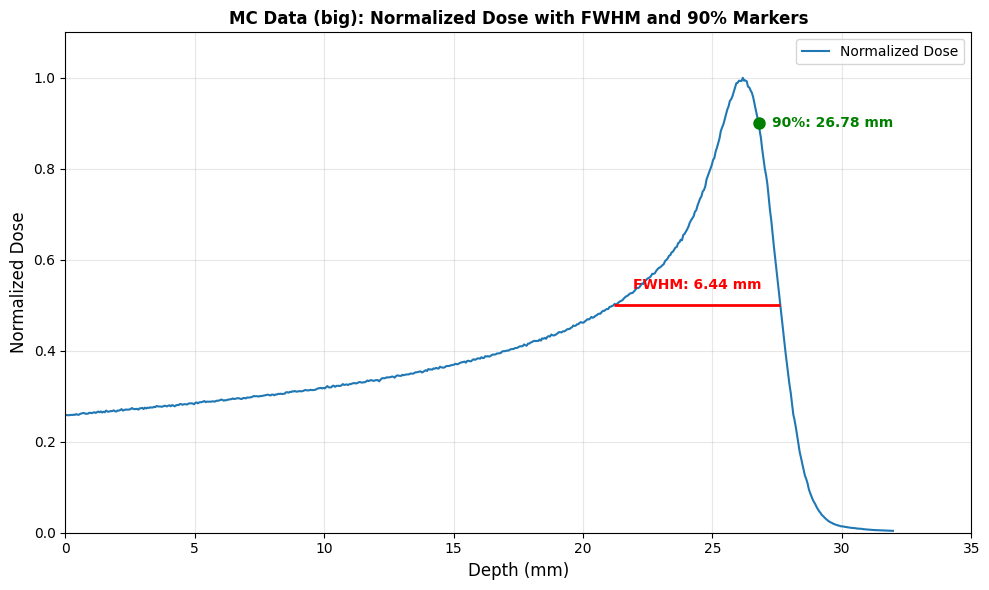

In [15]:
# Plot normalized dose with FWHM and 90% distal dose falloff markers

def find_fwhm_boundaries(depth, dose):
    """Find left and right FWHM boundaries."""
    max_val = dose.max()
    max_idx = dose.argmax()
    half_max = max_val / 2
    
    left_pos = None
    right_pos = None
    
    # Left side (before max)
    for i in range(max_idx - 1, -1, -1):
        if dose.iloc[i] < half_max <= dose.iloc[i + 1]:
            frac = (half_max - dose.iloc[i]) / (dose.iloc[i + 1] - dose.iloc[i])
            left_pos = depth.iloc[i] + frac * (depth.iloc[i + 1] - depth.iloc[i])
            break
    
    # Right side (after max)
    for i in range(max_idx, len(dose) - 1):
        if dose.iloc[i] >= half_max > dose.iloc[i + 1]:
            frac = (half_max - dose.iloc[i]) / (dose.iloc[i + 1] - dose.iloc[i])
            right_pos = depth.iloc[i] + frac * (depth.iloc[i + 1] - depth.iloc[i])
            break
    
    return left_pos, right_pos, half_max

def find_distal_percent_position(depth, dose, target_percent):
    """Find distal position where dose drops to target_percent of max."""
    max_val = dose.max()
    max_idx = dose.argmax()
    target_val = max_val * target_percent / 100.0
    
    # Search on distal (right) side after max
    for i in range(max_idx, len(dose) - 1):
        if dose.iloc[i] >= target_val > dose.iloc[i + 1]:
            frac = (target_val - dose.iloc[i]) / (dose.iloc[i + 1] - dose.iloc[i])
            x_pos = depth.iloc[i] + frac * (depth.iloc[i + 1] - depth.iloc[i])
            return x_pos, target_val
    return None, None

# Calculate FWHM and 90% position
left_fwhm, right_fwhm, half_max = find_fwhm_boundaries(df_mc['depth'], df_mc['dose'])
fwhm = right_fwhm - left_fwhm if (left_fwhm is not None and right_fwhm is not None) else None

x_90, dose_90 = find_distal_percent_position(df_mc['depth'], df_mc['dose'], 90)

print(f"FWHM: {fwhm:.2f} mm" if fwhm else "FWHM: Not found")
print(f"Left edge (50%): {left_fwhm:.2f} mm" if left_fwhm else "Left edge: Not found")
print(f"Right edge (50%): {right_fwhm:.2f} mm" if right_fwhm else "Right edge: Not found")
print(f"90% distal position: {x_90:.2f} mm" if x_90 else "90% position: Not found")

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot dose profile (line only, no markers)
ax.plot(df_mc['depth'], df_mc['dose'], color='tab:blue', linewidth=1.5, label='Normalized Dose')

# Add FWHM horizontal segment
if left_fwhm is not None and right_fwhm is not None:
    ax.hlines(y=half_max, xmin=left_fwhm, xmax=right_fwhm, color='red', linewidth=2, linestyle='-')
    ax.text((left_fwhm + right_fwhm) / 2, half_max + 0.03, f'FWHM: {fwhm:.2f} mm', 
            ha='center', va='bottom', color='red', fontsize=10, fontweight='bold')

# Add 90% marker
if x_90 is not None:
    ax.plot(x_90, dose_90, 'o', color='green', markersize=8)
    ax.text(x_90 + 0.5, dose_90, f'90%: {x_90:.2f} mm', 
            ha='left', va='center', color='green', fontsize=10, fontweight='bold')

ax.set_xlabel('Depth (mm)', fontsize=12)
ax.set_ylabel('Normalized Dose', fontsize=12)
ax.set_title('MC Data (big): Normalized Dose with FWHM and 90% Markers', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.1)
ax.set_xlim(0, 35)

plt.tight_layout()
plt.show()